# Predicting Daily Demand for Capital Bikeshare

## Regression Model Comparison and Temporal Robustness Testing

*MLN601 Assessment 3 - CRISP-DM*

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject:** Machine Learning (MLN601)
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment:** 3
- **Date:** August 2026

| Field | Scope |
|---|---|
| Dataset | UCI Bike Sharing, Capital Bikeshare daily and hourly files, Washington DC, 2011-2012 |
| Target | `cnt`: system-wide daily rentals |
| Primary question | Conditional daily-demand estimation from calendar attributes and expected weather |
| Secondary check | Rolling day-ahead temporal robustness, trained in 2011 and evaluated in 2012 |
| Method | Regression comparison within CRISP-DM |

## 1. Business Understanding

### 1.1 Business objective

Capital Bikeshare is a docked bicycle-sharing system. This project asks:

> **Given calendar attributes and expected weather conditions, how accurately can regression models estimate Capital Bikeshare's system-wide daily rental demand?**

Daily demand is total network rentals in one day. An accurate estimate could support fleet-capacity, staffing and maintenance planning. Station inventory and rebalancing are outside scope because the CSVs lack station identifiers, locations and capacity; station-level data could extend the work.

Lime in Sydney is a contemporary dockless analogy that motivates my interest and makes the assessment closer to my reality. Although its operations differ, it raises a parallel question: how could calendar and weather patterns inform fleet planning in a local system? It motivates the work but is not model evidence.

### 1.2 Data and prediction scope

Each row represents one system-wide day, with `cnt` as total rentals. Calendar attributes are known in advance. Observed weather proxies expected weather; real use would require forecasts. The hourly file supports exploration without changing the daily target.

The primary random 75/25 experiment estimates demand for days resembling 2011-2012 using calendar and weather without past demand. The secondary experiment tests transfer through time: selection uses 2011, then counts through day D plus next-day conditions predict D+1 in 2012. Forecasting all of 2012 on 1 January is separate because later counts would be unavailable.

### 1.3 Evaluation criteria

MAE is primary because it reports the average miss in rentals per day. RMSE gives more weight to large errors, while R-squared shows explained variation relative to predicting the sample mean.

The training-mean baseline tests whether predictors add value; the primary model must improve MAE by 40%. Rolling seven-day demand is the temporal reference because it adapts to recent demand; the frozen ML model must beat it by 5% on identical 2012 dates.

Model, feature and hyperparameter choices use training-only cross-validation. Lowest MAE leads; configurations within 5% are separated by RMSE and then simplicity. The holdout is used only after selection.

These study-defined criteria came from earlier exploratory versions and are not stakeholder-validated service levels.

### 1.4 Assumptions and limitations

- Observed weather omits forecast error, making reported day-ahead accuracy optimistic.
- Two years provide one year-on-year transition, weak evidence for persistent growth.
- Weather category 4 is absent; an input guard must restrict use to supported categories 1-3.
- System totals cannot answer station questions. The Institute for Transportation and Development Policy (ITDP) publishes bikeshare planning guidance; the National Association of City Transportation Officials (NACTO) publishes network and station-siting guidance. They explain why future station planning also needs identifiers, capacity, trip flows, transit connections and local demand (ITDP, 2018; NACTO, 2016).

## 2. Data Understanding

### 2.1 Source, loading and granularity

The UCI Bike Sharing dataset supplies `day.csv` and `hour.csv` for Capital Bikeshare in 2011-2012 (Fanaee-T & Gama, 2014). The daily file is the modelling source. The hourly file is loaded separately for intraday EDA and cross-file validation.

In [1]:
import os
import warnings
from pathlib import Path

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold, TimeSeriesSplit, cross_validate
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
DATA_DIR = BASE_DIR / "dataset"
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

day_df = pd.read_csv(DATA_DIR / "day.csv", parse_dates=["dteday"]).sort_values("dteday").reset_index(drop=True)
hour_df = pd.read_csv(DATA_DIR / "hour.csv", parse_dates=["dteday"]).sort_values(["dteday", "hr"]).reset_index(drop=True)
print("day.csv :", day_df.shape, day_df.dteday.min().date(), "to", day_df.dteday.max().date())
print("hour.csv:", hour_df.shape, hour_df.dteday.min().date(), "to", hour_df.dteday.max().date())

day.csv : (731, 16) 2011-01-01 to 2012-12-31
hour.csv: (17379, 17) 2011-01-01 to 2012-12-31


In [2]:
hourly_daily = hour_df.groupby("dteday", as_index=False)["cnt"].sum().rename(columns={"cnt": "hourly_sum"})
cross_file = day_df[["dteday", "cnt"]].merge(hourly_daily, on="dteday", how="outer", validate="one_to_one")
cross_file["difference"] = cross_file["hourly_sum"] - cross_file["cnt"]
assert len(cross_file) == 731
assert cross_file["difference"].eq(0).all(), "Hourly cnt does not sum to daily cnt for every date"
hours_per_date = hour_df.groupby("dteday").size()
incomplete_dates = int(hours_per_date.lt(24).sum())
omitted_hour_rows = int((24 - hours_per_date).sum())
assert incomplete_dates == 76 and omitted_hour_rows == 165

granularity = pd.DataFrame([
    {"file": "day.csv", "rows": len(day_df), "observation": "one daily prediction unit",
     "role": "selected for modelling"},
    {"file": "hour.csv", "rows": len(hour_df), "observation": "correlated hourly observations",
     "role": "intraday understanding and cross-file validation"},
])
print("Table 2.1 - Granularity and role")
display(granularity)
print(f"Cross-file validation passed: hourly cnt sums exactly to daily cnt on all {len(cross_file)} dates.")
print(f"Hourly panel audit: {incomplete_dates} dates have fewer than 24 rows; "
      f"{omitted_hour_rows} zero-demand hour rows are omitted in total.")

Table 2.1 - Granularity and role


,file,rows,observation,role
0,day.csv,731,one daily prediction unit,selected for modelling
1,hour.csv,17379,correlated hourly observations,intraday understanding and cross-file validation


Cross-file validation passed: hourly cnt sums exactly to daily cnt on all 731 dates.
Hourly panel audit: 76 dates have fewer than 24 rows; 165 zero-demand hour rows are omitted in total.


`hour.csv` is unbalanced: 76 of 731 dates have fewer than 24 observations, with 165 zero-demand rows omitted. An hourly model would change granularity, weight dates unequally and omit those periods. Selecting `day.csv` gives every target day one complete observation **to avoid hourly bias**. The hourly counts still reconstruct all daily totals and remain useful for intraday interpretation.

Table 2.2 - Peak hourly demand


,day_type,peak_hour,mean_cnt
13,Non-working day,13,372.7
41,Working day,17,525.3


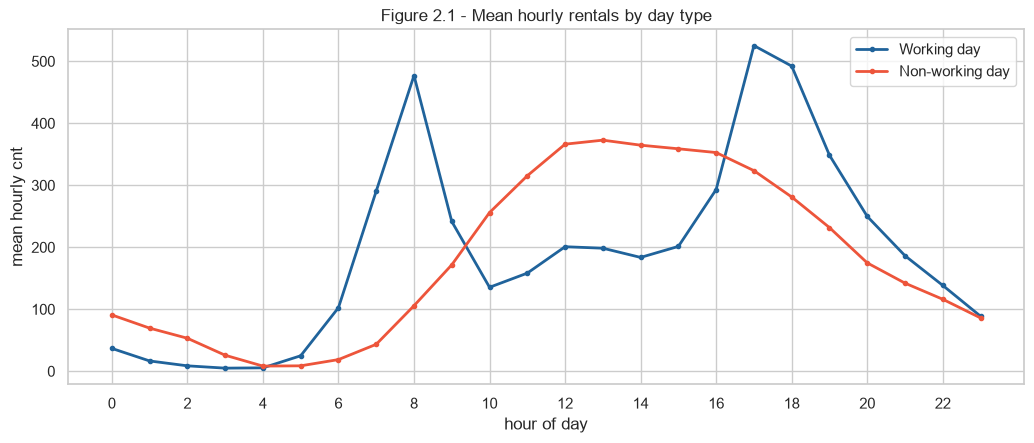

In [3]:
hour_profile = (hour_df.groupby(["workingday", "hr"], as_index=False)["cnt"].mean())
peaks = (hour_profile.loc[hour_profile.groupby("workingday")["cnt"].idxmax()]
         .assign(day_type=lambda x: x["workingday"].map({0: "Non-working day", 1: "Working day"}))
         [["day_type", "hr", "cnt"]].rename(columns={"hr": "peak_hour", "cnt": "mean_cnt"}))
peaks["mean_cnt"] = peaks["mean_cnt"].round(1)
print("Table 2.2 - Peak hourly demand")
display(peaks)
assert int(peaks.loc[peaks.day_type == "Working day", "peak_hour"].iloc[0]) == 17
assert np.isclose(peaks.loc[peaks.day_type == "Working day", "mean_cnt"].iloc[0], 525.3)
assert int(peaks.loc[peaks.day_type == "Non-working day", "peak_hour"].iloc[0]) == 13
assert np.isclose(peaks.loc[peaks.day_type == "Non-working day", "mean_cnt"].iloc[0], 372.7)

fig, ax = plt.subplots(figsize=(10.5, 4.6))
for flag, label, color in [(1, "Working day", "#20639B"), (0, "Non-working day", "#ED553B")]:
    p = hour_profile[hour_profile.workingday == flag]
    ax.plot(p.hr, p.cnt, marker="o", ms=3, lw=2, label=label, color=color)
ax.set(title="Figure 2.1 - Mean hourly rentals by day type", xlabel="hour of day", ylabel="mean hourly cnt")
ax.set_xticks(range(0, 24, 2)); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_hourly_demand.png", dpi=160); plt.show()

Working-day demand peaks at 17:00 (525.3 rentals), while non-working-day demand peaks at 13:00 (372.7). The profiles are consistent with commute-oriented and broader daytime use, respectively; aggregate counts do not prove trip purpose.

In [4]:
span_days = (day_df.dteday.max() - day_df.dteday.min()).days + 1
norm_cols = ["temp", "atemp", "hum", "windspeed"]
quality = pd.DataFrame([
    ("Daily rows equal calendar span", len(day_df) == span_days, f"{len(day_df)} rows / {span_days} days"),
    ("No date gaps", day_df.dteday.diff().dropna().dt.days.max() == 1, "daily continuity"),
    ("No exact duplicates", day_df.duplicated().sum() == 0, f"{day_df.duplicated().sum()} duplicates"),
    ("No source missing values", day_df.isna().sum().sum() == 0, f"{day_df.isna().sum().sum()} missing"),
    ("casual + registered = cnt", (day_df.casual + day_df.registered == day_df.cnt).all(), "all rows"),
    ("Normalised weather in [0,1]", all(day_df[c].between(0, 1).all() for c in norm_cols), "all four columns"),
    ("Humidity above zero", (day_df.hum > 0).all(), f"{int((day_df.hum == 0).sum())} zero reading"),
    ("Daily weather categories supported", set(day_df.weathersit.unique()) == {1, 2, 3}, "category 4 absent"),
], columns=["check", "pass", "evidence"])
print("Table 2.3 - Data quality audit")
display(quality)

zero_hum_date = day_df.loc[day_df.hum.eq(0), "dteday"].iloc[0]
zero_hour_rows = hour_df[hour_df.dteday.eq(zero_hum_date)]
print("Zero-humidity date:", zero_hum_date.date(), "| hourly rows:", len(zero_hour_rows),
      "| hourly humidity values:", sorted(zero_hour_rows.hum.unique()))

# Keep a raw frame for sensitivity analysis, then mark the implausible value missing.
raw_day_df = day_df.copy()
day_df.loc[day_df.hum.eq(0), "hum"] = np.nan
assert day_df.hum.isna().sum() == 1

Table 2.3 - Data quality audit


,check,pass,evidence
0,Daily rows equal calendar span,True,731 rows / 731 days
1,No date gaps,True,daily continuity
2,No exact duplicates,True,0 duplicates
3,No source missing values,True,0 missing
4,casual + registered = cnt,True,all rows
5,"Normalised weather in [0,1]",True,all four columns
6,Humidity above zero,False,1 zero reading
7,Daily weather categories supported,True,category 4 absent


Zero-humidity date: 2011-03-10 | hourly rows: 22 | hourly humidity values: [np.float64(0.0)]


The daily series is complete and `casual + registered = cnt` holds throughout. One date reports zero humidity across 22 hourly rows. It is treated as a recording fault, changed to missing and median-imputed inside each training fold; a sensitivity check tests the decision. Plausible tail values are retained.

Weather category 4 is absent, so the supported domain is 1-3 and still requires an input guard.

### 2.2 Variables and exploratory analysis

| Variables | Role |
|---|---|
| `cnt` | Continuous target: system-wide rentals per day |
| `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday` | Calendar predictors |
| `weathersit`, `temp`, `atemp`, `hum`, `windspeed` | Weather predictors |
| `dteday` | Ordering and elapsed-time construction; not passed directly to a model |
| `casual`, `registered` | Descriptive plots only; excluded because they sum exactly to `cnt` |

`casual` and `registered` describe user groups, not independent predictors. Registered users may include commuters, but membership status does not prove trip purpose.

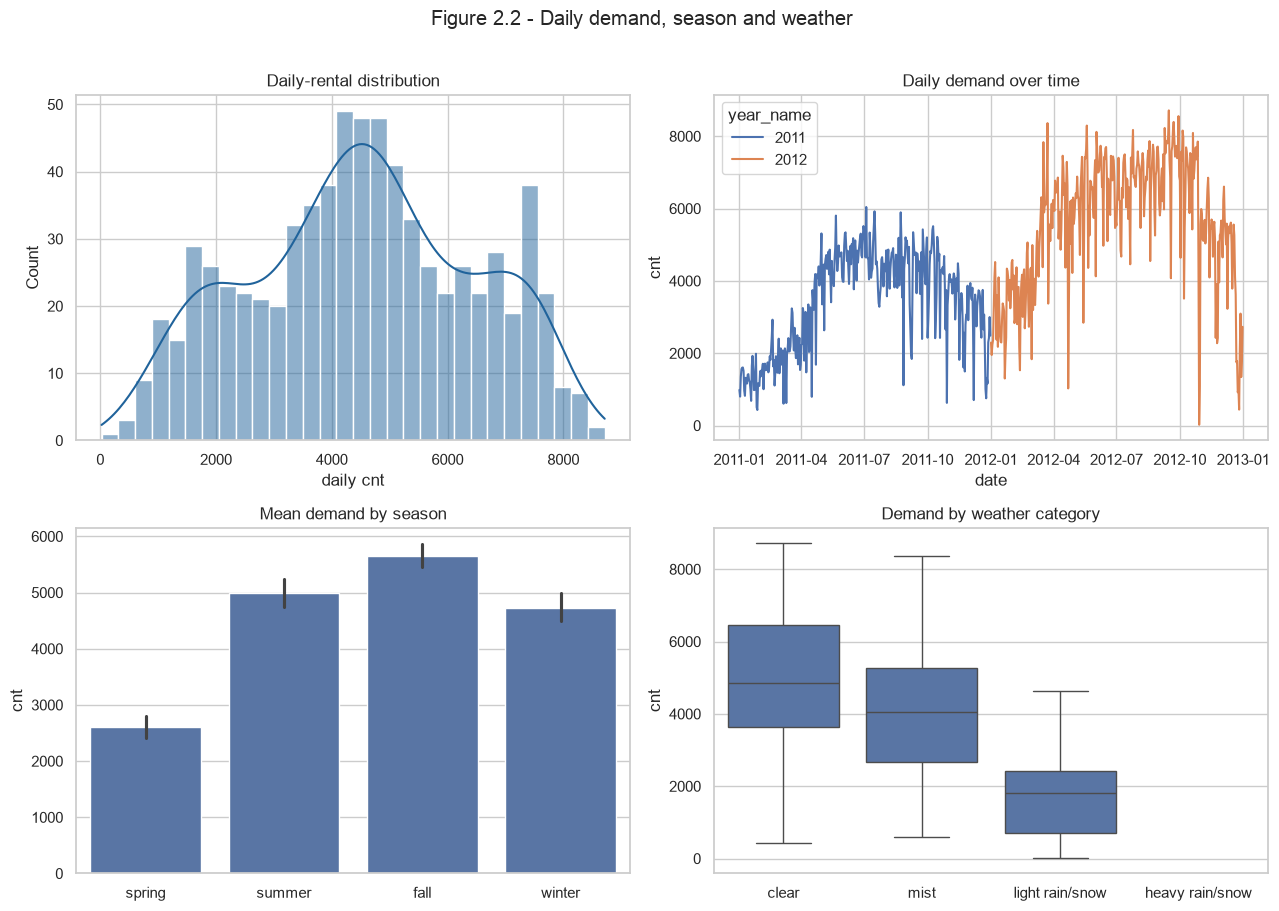

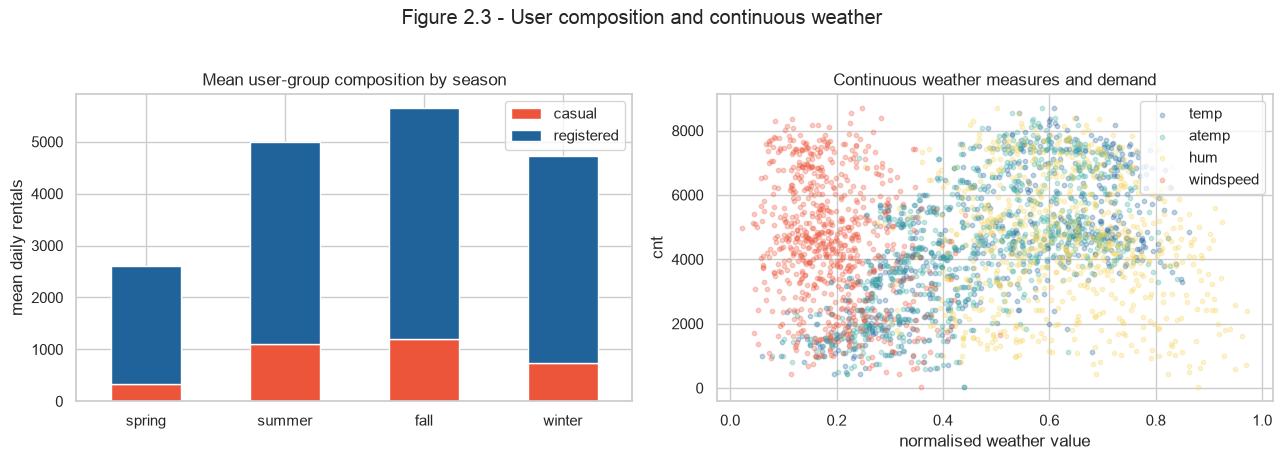

In [5]:
season_lbl = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_lbl = {1: "clear", 2: "mist", 3: "light rain/snow", 4: "heavy rain/snow"}
day_df["season_name"] = day_df.season.map(season_lbl)
day_df["weather_name"] = day_df.weathersit.map(weather_lbl)
day_df["year_name"] = day_df.yr.map({0: "2011", 1: "2012"})

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(day_df.cnt, bins=30, kde=True, ax=ax[0, 0], color="#20639B")
ax[0, 0].set(title="Daily-rental distribution", xlabel="daily cnt")
sns.lineplot(data=day_df, x="dteday", y="cnt", hue="year_name", ax=ax[0, 1])
ax[0, 1].set(title="Daily demand over time", xlabel="date", ylabel="cnt")
sns.barplot(data=day_df, x="season_name", y="cnt", order=["spring", "summer", "fall", "winter"], ax=ax[1, 0])
ax[1, 0].set(title="Mean demand by season", xlabel="")
sns.boxplot(data=day_df, x="weather_name", y="cnt", order=["clear", "mist", "light rain/snow", "heavy rain/snow"], ax=ax[1, 1])
ax[1, 1].set(title="Demand by weather category", xlabel="")
fig.suptitle("Figure 2.2 - Daily demand, season and weather", y=1.01)
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_daily_eda.png", dpi=150); plt.show()

comp = day_df.groupby("season_name")[["casual", "registered"]].mean().reindex(["spring", "summer", "fall", "winter"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
comp.plot(kind="bar", stacked=True, ax=ax[0], color=["#ED553B", "#20639B"])
ax[0].set(title="Mean user-group composition by season", xlabel="", ylabel="mean daily rentals")
ax[0].tick_params(axis="x", rotation=0)
for c, color in zip(["temp", "atemp", "hum", "windspeed"], ["#20639B", "#3CAEA3", "#F6D55C", "#ED553B"]):
    ax[1].scatter(day_df[c], day_df.cnt, s=10, alpha=.28, label=c, color=color)
ax[1].set(title="Continuous weather measures and demand", xlabel="normalised weather value", ylabel="cnt")
ax[1].legend()
fig.suptitle("Figure 2.3 - User composition and continuous weather", y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_composition_weather.png", dpi=150); plt.show()

Demand rises across the two years, peaks in warmer seasons and falls in adverse weather. Registered users provide most rentals, while the casual share expands in warmer seasons. Both user columns remain descriptive because they sum to the target.

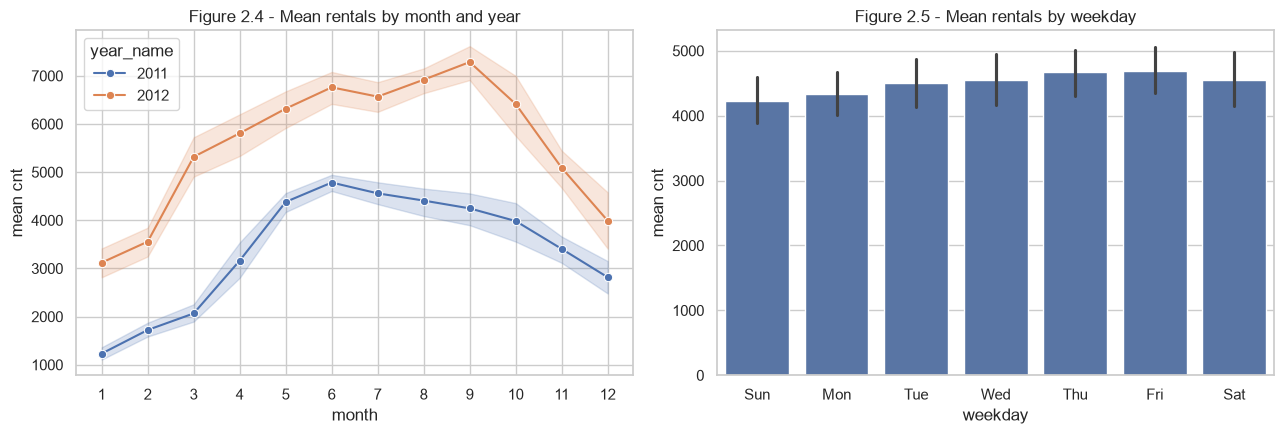

In [6]:
weekday_lbl = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
day_df["weekday_name"] = day_df.weekday.map(weekday_lbl)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=day_df, x="mnth", y="cnt", hue="year_name", marker="o", ax=ax[0])
ax[0].set(title="Figure 2.4 - Mean rentals by month and year", xlabel="month", ylabel="mean cnt")
ax[0].set_xticks(range(1, 13))
sns.barplot(data=day_df, x="weekday_name", y="cnt",
            order=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], ax=ax[1])
ax[1].set(title="Figure 2.5 - Mean rentals by weekday", xlabel="weekday", ylabel="mean cnt")
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_month_weekday.png", dpi=160); plt.show()

Monthly demand follows the seasonal wave and every 2012 month exceeds its 2011 counterpart. Weekday means vary much less, showing that aggregation blends working-day and leisure patterns visible in the hourly profiles.

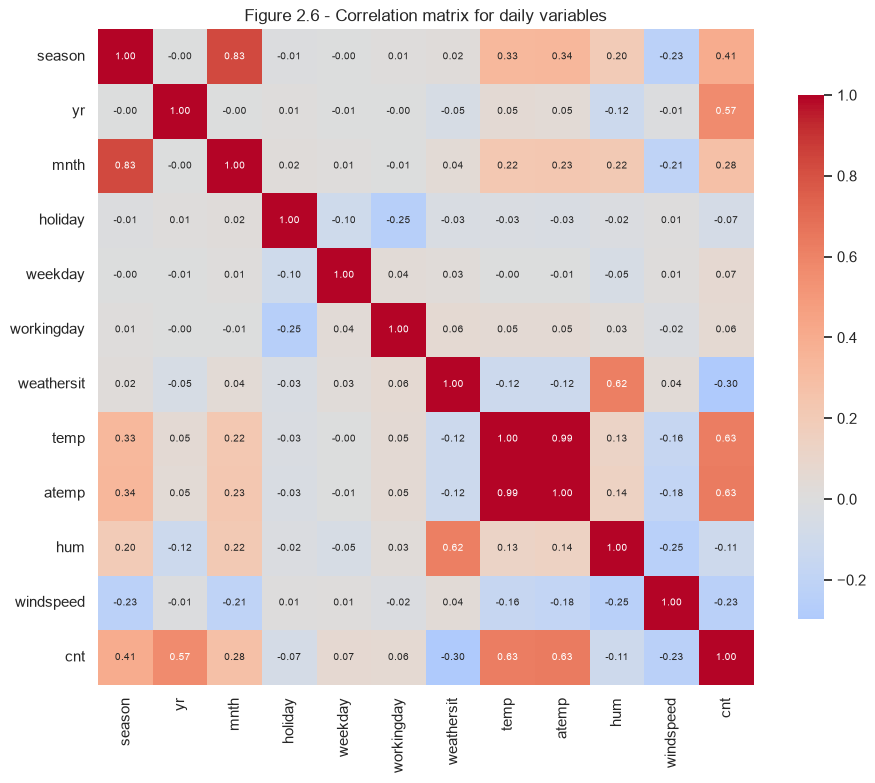

Table 2.4 - Correlations with cnt


,correlation_with_cnt
atemp,0.631
temp,0.627
yr,0.567
season,0.406
mnth,0.280
weekday,0.067
workingday,0.061
holiday,-0.068
hum,-0.115
windspeed,-0.235


In [7]:
corr_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday",
             "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]
corr_matrix = day_df[corr_cols].corr()
cnt_correlations = corr_matrix["cnt"].drop("cnt").sort_values(ascending=False)
assert cnt_correlations.index[0] == "atemp"
assert cnt_correlations.loc["weathersit"] < 0 and cnt_correlations.loc["windspeed"] < 0

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 7})
plt.title("Figure 2.6 - Correlation matrix for daily variables")
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_correlation_heatmap.png", dpi=160); plt.show()
print("Table 2.4 - Correlations with cnt")
display(cnt_correlations.round(3).to_frame("correlation_with_cnt"))

`atemp` has the highest correlation with `cnt` (+0.631), followed by `temp` (+0.627) and `yr` (+0.567). Adverse weather (`weathersit`, -0.297), windspeed (-0.235) and corrected humidity (-0.115) are negative. The near-collinearity of `temp` and `atemp` cautions against interpreting linear coefficients independently; categorical codes also limit causal interpretation.

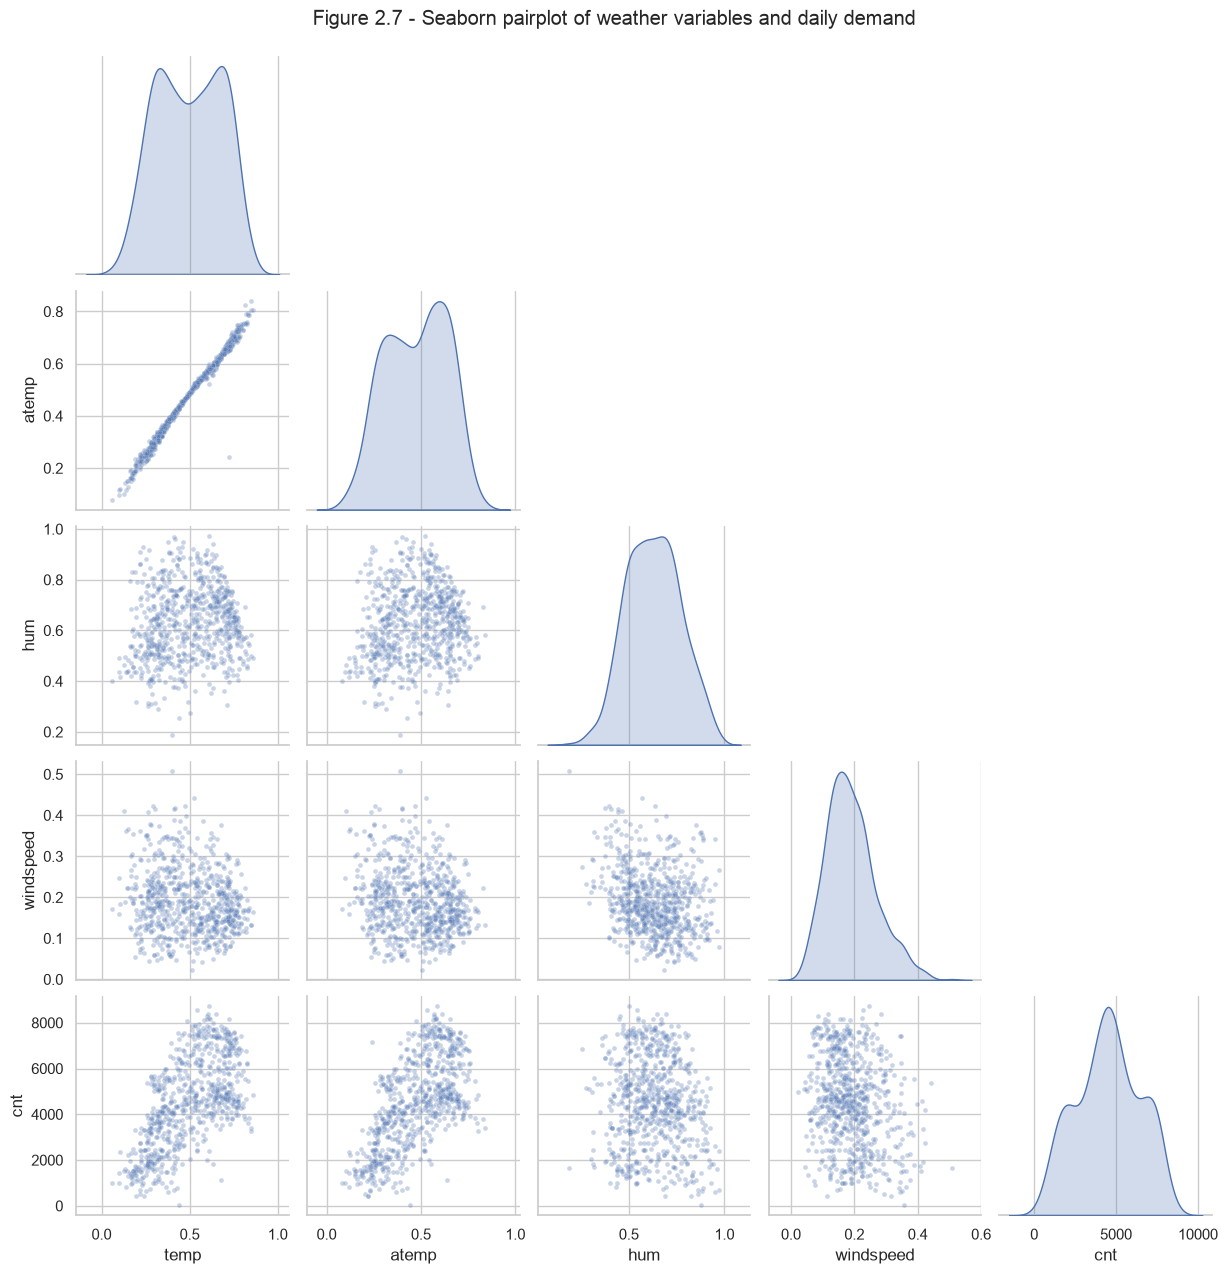

In [8]:
# Stage 2.6: use seaborn's pairplot function and include its output.
pairplot_data = day_df[["temp", "atemp", "hum", "windspeed", "cnt"]].dropna()
pair_grid = sns.pairplot(pairplot_data, corner=True, diag_kind="kde",
                         plot_kws={"alpha": .3, "s": 12})
pair_grid.fig.suptitle("Figure 2.7 - Seaborn pairplot of weather variables and daily demand", y=1.02)
pair_grid.savefig(FIG_DIR / "v4_pairplot.png", dpi=140, bbox_inches="tight")
plt.show()

The pairplot confirms positive, nonlinear relationships between demand and both temperature measures. Humidity and windspeed show weaker negative patterns and broad scatter. `temp` and `atemp` move almost identically, consistent with their high correlation, while no single weather variable fully explains demand.

## 3. Data Preparation

Two frames prevent the temporal question from shrinking the primary sample. `primary_df` contains all 731 days and no past-demand inputs. `temporal_df` starts after a causal seven-day warm-up and contains 724 days.

In [9]:
# Shared calendar/weather engineering. Interactions use only target-day exogenous inputs.
day_df["atemp_hum"] = day_df["atemp"] * day_df["hum"]
day_df["temp_sq"] = day_df["temp"] ** 2
day_df["days_since_start"] = (day_df.dteday - day_df.dteday.min()).dt.days
day_df["mnth_sin"], day_df["mnth_cos"] = np.sin(2*np.pi*day_df.mnth/12), np.cos(2*np.pi*day_df.mnth/12)
day_df["weekday_sin"], day_df["weekday_cos"] = np.sin(2*np.pi*day_df.weekday/7), np.cos(2*np.pi*day_df.weekday/7)
day_df["season_sin"], day_df["season_cos"] = np.sin(2*np.pi*day_df.season/4), np.cos(2*np.pi*day_df.season/4)

primary_df = day_df.copy().reset_index(drop=True)

# Causal temporal features: every window ends before the target day.
day_df["lag_1_cnt"] = day_df.cnt.shift(1)
day_df["lag_7_cnt"] = day_df.cnt.shift(7)
day_df["roll_7_cnt"] = day_df.cnt.shift(1).rolling(7).mean()
assert day_df.lag_1_cnt.equals(day_df.cnt.shift(1))
assert day_df.lag_7_cnt.equals(day_df.cnt.shift(7))
for i in range(7, len(day_df)):
    assert np.isclose(day_df.loc[i, "roll_7_cnt"], day_df.loc[i-7:i-1, "cnt"].mean())
temporal_df = day_df.dropna(subset=["roll_7_cnt"]).reset_index(drop=True)

assert len(primary_df) == 731
assert len(temporal_df) == 724
print("primary_df rows:", len(primary_df), "| temporal_df rows:", len(temporal_df))

primary_df rows: 731 | temporal_df rows: 724


In [10]:
PRIMARY_NOMINAL = ["season", "mnth", "weekday", "weathersit"]
PRIMARY_BINARY = ["yr", "holiday", "workingday"]
WEATHER = ["temp", "atemp", "hum", "windspeed"]
CYCLICAL = ["mnth_sin", "mnth_cos", "weekday_sin", "weekday_cos", "season_sin", "season_cos"]
INTERACTIONS = ["atemp_hum", "temp_sq"]
TREND = ["days_since_start"]
AUTOREGRESSIVE = ["lag_1_cnt", "lag_7_cnt", "roll_7_cnt"]

PRIMARY_FEATURE_SETS = {
    "core": PRIMARY_NOMINAL + PRIMARY_BINARY + WEATHER,
    "core + interactions": PRIMARY_NOMINAL + PRIMARY_BINARY + WEATHER + INTERACTIONS,
    "core + interactions + trend": PRIMARY_NOMINAL + PRIMARY_BINARY + WEATHER + INTERACTIONS + TREND,
}
TEMPORAL_FEATURE_SETS = {
    "core": ["weathersit", "holiday", "workingday"] + WEATHER + CYCLICAL,
    "core + interactions": ["weathersit", "holiday", "workingday"] + WEATHER + CYCLICAL + INTERACTIONS,
    "core + interactions + autoregressive": ["weathersit", "holiday", "workingday"] + WEATHER + CYCLICAL + INTERACTIONS + AUTOREGRESSIVE,
    "core + interactions + autoregressive + trend": ["weathersit", "holiday", "workingday"] + WEATHER + CYCLICAL + INTERACTIONS + AUTOREGRESSIVE + TREND,
}

for feature_list in list(PRIMARY_FEATURE_SETS.values()) + list(TEMPORAL_FEATURE_SETS.values()):
    assert "casual" not in feature_list and "registered" not in feature_list
assert all(c not in cols for cols in PRIMARY_FEATURE_SETS.values() for c in AUTOREGRESSIVE)
assert all("yr" not in cols for cols in TEMPORAL_FEATURE_SETS.values())

def make_preprocessor(columns, temporal=False):
    nominal = ["weathersit"] if temporal else [c for c in PRIMARY_NOMINAL if c in columns]
    binary_pool = ["holiday", "workingday"] + ([] if temporal else ["yr"])
    binary = [c for c in binary_pool if c in columns]
    continuous = [c for c in columns if c not in nominal + binary]
    return ColumnTransformer([
        ("nominal", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal),
        ("continuous", Pipeline([("impute", SimpleImputer(strategy="median")),
                                  ("scale", StandardScaler())]), continuous),
        ("binary", "passthrough", binary),
    ])

def pipeline_for(model, columns, temporal=False):
    return Pipeline([("prep", make_preprocessor(columns, temporal=temporal)), ("model", model)])

def metrics(y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    return {"MAE": mean_absolute_error(y_true, predictions), "MSE": mse,
            "RMSE": float(np.sqrt(mse)), "R2": r2_score(y_true, predictions)}

GRIDS = {
    "Linear Regression": (LinearRegression(), {}),
    "K-Nearest Neighbors": (KNeighborsRegressor(), {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15], "model__weights": ["uniform", "distance"]}),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), {
        "model__n_estimators": [200, 400], "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 2, 4]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [200, 400], "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]}),
}

MODEL_SIMPLICITY = {"Linear Regression": 1, "K-Nearest Neighbors": 2,
                    "Random Forest": 3, "Gradient Boosting": 4}
FEATURE_SIMPLICITY = {name: i for i, name in enumerate(
    ["core", "core + interactions", "core + interactions + trend",
     "core + interactions + autoregressive", "core + interactions + autoregressive + trend"], 1)}

def compact_params(params):
    if not params:
        return "default"
    labels = {"model__learning_rate": "lr", "model__max_depth": "depth",
              "model__n_estimators": "estimators", "model__min_samples_leaf": "leaf",
              "model__n_neighbors": "neighbors", "model__weights": "weights"}
    return "; ".join(f"{labels.get(key, key)}={value}" for key, value in params.items())

def choose_configuration(rows):
    frame = pd.DataFrame(rows).copy()
    best_mae = frame["cv_mean_MAE"].min()
    shortlist = frame[frame["cv_mean_MAE"] <= 1.05 * best_mae].copy()
    shortlist["simplicity"] = shortlist["model"].map(MODEL_SIMPLICITY) + shortlist["feature_set"].map(FEATURE_SIMPLICITY) / 10
    return shortlist.sort_values(["cv_mean_RMSE", "simplicity", "cv_mean_MAE"]).iloc[0]

## 4. Modelling

Four regression families are compared with lightweight grids. Linear Regression tests a global additive relationship; K-Nearest Neighbors tests local similarity; Random Forest averages decorrelated trees; Gradient Boosting sequentially corrects residuals. Scaling and fold-fitted median imputation live inside every pipeline.

### 4.1 Primary model comparison: random 75/25 holdout

The split is created once with `random_state=42`. Only the 75% training partition participates in family, feature-set and hyperparameter selection. Each of the 12 family/feature-set combinations uses shuffled five-fold `KFold` and MAE scoring. The 25% holdout is accessed only after the global configuration and one configuration per family have been frozen.

In [11]:
all_indices = primary_df.index.to_numpy()
primary_train_idx, primary_holdout_idx = train_test_split(
    all_indices, test_size=0.25, random_state=RANDOM_STATE
)
assert set(primary_train_idx).isdisjoint(primary_holdout_idx)
assert len(primary_train_idx) == 548 and len(primary_holdout_idx) == 183

primary_train = primary_df.loc[primary_train_idx].copy()
primary_holdout = primary_df.loc[primary_holdout_idx].copy()
primary_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
primary_rows, primary_estimators = [], {}

for feature_name, columns in PRIMARY_FEATURE_SETS.items():
    for model_name, (estimator, grid) in GRIDS.items():
        search = GridSearchCV(
            pipeline_for(clone(estimator), columns, temporal=False), grid,
            scoring="neg_mean_absolute_error", cv=primary_cv, n_jobs=1, refit=True
        )
        search.fit(primary_train[columns], primary_train.cnt)
        rmse_cv = cross_validate(
            search.best_estimator_, primary_train[columns], primary_train.cnt,
            cv=primary_cv, scoring="neg_root_mean_squared_error", n_jobs=1
        )["test_score"]
        row = {
            "model": model_name, "feature_set": feature_name,
            "cv_mean_MAE": -search.best_score_,
            "cv_std_MAE": search.cv_results_["std_test_score"][search.best_index_],
            "cv_mean_RMSE": -rmse_cv.mean(), "cv_std_RMSE": rmse_cv.std(),
            "best_params": compact_params(search.best_params_),
        }
        primary_rows.append(row)
        primary_estimators[(model_name, feature_name)] = search.best_estimator_

primary_cv_table = (pd.DataFrame(primary_rows)
                    .sort_values(["cv_mean_MAE", "cv_mean_RMSE"])
                    .reset_index(drop=True))
primary_cv_table.to_csv(OUTPUT_DIR / "primary_cv_selection_v4.csv", index=False)

primary_choice = choose_configuration(primary_rows)
primary_family_choices = {
    family: choose_configuration([r for r in primary_rows if r["model"] == family])
    for family in GRIDS
}
primary_winner_name = primary_choice["model"]
primary_winner_features = primary_choice["feature_set"]
primary_winner_columns = PRIMARY_FEATURE_SETS[primary_winner_features]
primary_winner = primary_estimators[(primary_winner_name, primary_winner_features)]

# Leakage audit: choices contain CV statistics from training indices only; the holdout has not
# been passed to fit, GridSearchCV, cross_validate or choose_configuration.
selection_indices = set(primary_train_idx)
assert selection_indices.isdisjoint(set(primary_holdout_idx))
assert len(primary_df) == 731
print("Table 4.1 - Primary CV selection (training partition only)")
display(primary_cv_table.round({"cv_mean_MAE": 1, "cv_std_MAE": 1,
                                "cv_mean_RMSE": 1, "cv_std_RMSE": 1}))
print("Frozen primary configuration:", primary_winner_name, "|", primary_winner_features,
      "|", primary_choice["best_params"])

Table 4.1 - Primary CV selection (training partition only)


,model,feature_set,cv_mean_MAE,cv_std_MAE,cv_mean_RMSE,cv_std_RMSE,best_params
0,Gradient Boosting,core + interactions + trend,477.0,34.1,657.6,45.4,lr=0.1; depth=2; estimators=400
1,Random Forest,core + interactions + trend,498.0,18.1,723.5,38.5,depth=16; leaf=1; estimators=200
2,Gradient Boosting,core,513.8,56.4,690.8,53.2,lr=0.05; depth=2; estimators=400
3,Gradient Boosting,core + interactions,519.5,47.4,697.1,46.4,lr=0.05; depth=2; estimators=400
4,Random Forest,core,533.6,26.5,746.8,25.7,depth=16; leaf=1; estimators=400
5,Random Forest,core + interactions,539.1,24.3,752.6,23.2,depth=16; leaf=1; estimators=400
6,Linear Regression,core + interactions + trend,559.3,19.8,752.4,36.9,default
7,Linear Regression,core + interactions,560.4,19.3,752.6,38.5,default
8,K-Nearest Neighbors,core + interactions + trend,563.0,15.1,794.0,40.0,neighbors=7; weights=distance
9,Linear Regression,core,591.0,14.7,806.8,41.9,default


Frozen primary configuration: Gradient Boosting | core + interactions + trend | lr=0.1; depth=2; estimators=400


In [12]:
# First use of the fixed 25% holdout: score one training-selected configuration per family.
primary_holdout_rows = []
mean_model = DummyRegressor(strategy="mean").fit(
    np.zeros((len(primary_train), 1)), primary_train.cnt
)
baseline_pred = mean_model.predict(np.zeros((len(primary_holdout), 1)))
primary_holdout_rows.append({"model": "Mean baseline", "feature_set": "constant training mean",
                             "best_params": "default", **metrics(primary_holdout.cnt, baseline_pred)})

primary_family_predictions = {}
for family, choice in primary_family_choices.items():
    feature_name = choice["feature_set"]
    columns = PRIMARY_FEATURE_SETS[feature_name]
    fitted = primary_estimators[(family, feature_name)]
    pred = fitted.predict(primary_holdout[columns])
    primary_family_predictions[family] = pred
    primary_holdout_rows.append({"model": family, "feature_set": feature_name,
                                 "best_params": choice["best_params"],
                                 **metrics(primary_holdout.cnt, pred)})

primary_holdout_table = (pd.DataFrame(primary_holdout_rows)
                         .sort_values("MAE").reset_index(drop=True))
primary_holdout_table.to_csv(OUTPUT_DIR / "primary_holdout_metrics_v4.csv", index=False)
primary_metrics = primary_holdout_table.loc[
    primary_holdout_table.model.eq(primary_winner_name)
].iloc[0]
primary_baseline = primary_holdout_table.loc[
    primary_holdout_table.model.eq("Mean baseline")
].iloc[0]
primary_improvement = 1 - primary_metrics.MAE / primary_baseline.MAE
primary_mae_pct = primary_metrics.MAE / primary_holdout.cnt.mean()
primary_summary = pd.DataFrame([{
    "selected_model": primary_winner_name,
    "feature_set": primary_winner_features,
    "best_params": primary_choice["best_params"],
    "holdout_MAE": primary_metrics.MAE,
    "holdout_RMSE": primary_metrics.RMSE,
    "holdout_R2": primary_metrics.R2,
    "mean_baseline_MAE": primary_baseline.MAE,
    "baseline_improvement_pct": 100 * primary_improvement,
    "MAE_pct_of_holdout_mean_demand": 100 * primary_mae_pct,
}])
primary_summary.to_csv(OUTPUT_DIR / "primary_summary_v4.csv", index=False)
print("Table 4.2 - Frozen family configurations on the primary holdout")
display(primary_holdout_table.round({"MAE": 1, "MSE": 1, "RMSE": 1, "R2": 3}))
print("Table 4.3 - Final selected-model summary")
display(primary_summary.round(3))

Table 4.2 - Frozen family configurations on the primary holdout


,model,feature_set,best_params,MAE,MSE,RMSE,R2
0,Gradient Boosting,core + interactions + trend,lr=0.1; depth=2; estimators=400,433.9,397608.0,630.6,0.897
1,Random Forest,core + interactions + trend,depth=16; leaf=1; estimators=200,446.6,463735.1,681.0,0.880
2,K-Nearest Neighbors,core + interactions + trend,neighbors=7; weights=distance,501.0,612073.9,782.4,0.841
3,Linear Regression,core + interactions + trend,default,529.9,524664.9,724.3,0.864
4,Mean baseline,constant training mean,default,1663.0,3933577.2,1983.3,-0.021


Table 4.3 - Final selected-model summary


,selected_model,feature_set,best_params,holdout_MAE,holdout_RMSE,holdout_R2,mean_baseline_MAE,baseline_improvement_pct,MAE_pct_of_holdout_mean_demand
0,Gradient Boosting,core + interactions + trend,lr=0.1; depth=2; estimators=400,433.863,630.562,0.897,1662.978,73.91,10.107


In [13]:
# Sensitivity of the frozen primary winner to retaining the raw hum=0 record.
raw_primary = primary_df.copy()
raw_primary.loc[raw_primary.dteday.eq(zero_hum_date), "hum"] = 0.0
raw_primary["atemp_hum"] = raw_primary.atemp * raw_primary.hum
sens_model = clone(primary_winner).fit(
    raw_primary.loc[primary_train_idx, primary_winner_columns],
    raw_primary.loc[primary_train_idx, "cnt"]
)
sens_pred = sens_model.predict(raw_primary.loc[primary_holdout_idx, primary_winner_columns])
corrected_pred = primary_winner.predict(primary_holdout[primary_winner_columns])
humidity_sensitivity = pd.DataFrame([
    {"treatment": "hum=0 marked missing; fold-fitted median imputation",
     **metrics(primary_holdout.cnt, corrected_pred)},
    {"treatment": "raw hum=0 retained", **metrics(primary_holdout.cnt, sens_pred)},
])
humidity_sensitivity.to_csv(OUTPUT_DIR / "humidity_sensitivity_v4.csv", index=False)
print("Table 4.4 - Humidity correction sensitivity on the frozen primary model")
display(humidity_sensitivity.round({"MAE": 2, "MSE": 1, "RMSE": 2, "R2": 4}))

Table 4.4 - Humidity correction sensitivity on the frozen primary model


,treatment,MAE,MSE,RMSE,R2
0,hum=0 marked missing; fold-fitted median imput...,433.86,397608.0,630.56,0.8968
1,raw hum=0 retained,430.85,397549.6,630.52,0.8968


**Primary result.** Gradient Boosting with interactions and elapsed-time trend was frozen at CV MAE 477.0 (SD 34.1) and RMSE 657.6. Random Forest entered the 5% shortlist at MAE 498.0 but had higher RMSE (723.5). The selected grid point used learning rate 0.1, depth 2 and 400 estimators.

On the untouched 183-day holdout it reached MAE 433.9, RMSE 630.6 and R-squared 0.897. MAE was 73.9% below the baseline's 1,663.0 and equalled **10.1% of mean holdout demand**, meeting the 40% criterion. Random Forest reached 446.6, KNN 501.0 and Linear Regression 529.9; the winner remained frozen.

Marking zero humidity missing produced MAE 433.9 versus 430.9 when retained. The sub-1% difference leaves the conclusion unchanged; fold-fitted imputation preserves the physically plausible treatment.

### 4.2 Secondary temporal robustness check

Selection now uses `TimeSeriesSplit(n_splits=3)` inside 2011. The temporal design excludes `yr`, which is constant in the training year. It compares core cyclical calendar/weather inputs, interactions, causal recent-demand inputs and an optional elapsed-time trend. One configuration per family and the global temporal configuration are frozen before any 2012 score is produced.

In [14]:
temporal_train = temporal_df[temporal_df.yr.eq(0)].copy().reset_index(drop=True)
temporal_test = temporal_df[temporal_df.yr.eq(1)].copy().reset_index(drop=True)
assert temporal_train.dteday.max() < pd.Timestamp("2012-01-01")
assert temporal_test.dteday.min() >= pd.Timestamp("2012-01-01")
assert all("yr" not in columns for columns in TEMPORAL_FEATURE_SETS.values())

temporal_cv = TimeSeriesSplit(n_splits=3)
fold_table = []
for fold, (tr, va) in enumerate(temporal_cv.split(temporal_train), 1):
    fold_table.append({
        "fold": fold, "train_rows": len(tr), "validation_rows": len(va),
        "train_window": f"{temporal_train.dteday.iloc[tr[0]].date()} to {temporal_train.dteday.iloc[tr[-1]].date()}",
        "validation_window": f"{temporal_train.dteday.iloc[va[0]].date()} to {temporal_train.dteday.iloc[va[-1]].date()}",
    })
print("Table 4.5 - TimeSeriesSplit folds within 2011")
display(pd.DataFrame(fold_table))

temporal_rows, temporal_estimators = [], {}
for feature_name, columns in TEMPORAL_FEATURE_SETS.items():
    for model_name, (estimator, grid) in GRIDS.items():
        search = GridSearchCV(
            pipeline_for(clone(estimator), columns, temporal=True), grid,
            scoring="neg_mean_absolute_error", cv=temporal_cv, n_jobs=1, refit=True
        )
        search.fit(temporal_train[columns], temporal_train.cnt)
        rmse_cv = cross_validate(
            search.best_estimator_, temporal_train[columns], temporal_train.cnt,
            cv=temporal_cv, scoring="neg_root_mean_squared_error", n_jobs=1
        )["test_score"]
        row = {"model": model_name, "feature_set": feature_name,
               "cv_mean_MAE": -search.best_score_,
               "cv_std_MAE": search.cv_results_["std_test_score"][search.best_index_],
               "cv_mean_RMSE": -rmse_cv.mean(), "cv_std_RMSE": rmse_cv.std(),
               "best_params": compact_params(search.best_params_)}
        temporal_rows.append(row)
        temporal_estimators[(model_name, feature_name)] = search.best_estimator_

temporal_cv_table = (pd.DataFrame(temporal_rows)
                     .sort_values(["cv_mean_MAE", "cv_mean_RMSE"]).reset_index(drop=True))
temporal_cv_table.to_csv(OUTPUT_DIR / "temporal_cv_selection_v4.csv", index=False)
temporal_choice = choose_configuration(temporal_rows)
temporal_family_choices = {
    family: choose_configuration([r for r in temporal_rows if r["model"] == family])
    for family in GRIDS
}
temporal_winner_name = temporal_choice["model"]
temporal_winner_features = temporal_choice["feature_set"]
temporal_winner = temporal_estimators[(temporal_winner_name, temporal_winner_features)]

# Selection records and fitted estimators contain 2011 only. 2012 has not been scored yet.
assert temporal_train.yr.eq(0).all()
assert not temporal_train.dteday.isin(temporal_test.dteday).any()
print("Table 4.6 - Temporal CV selection (2011 only)")
display(temporal_cv_table.round({"cv_mean_MAE": 1, "cv_std_MAE": 1,
                                 "cv_mean_RMSE": 1, "cv_std_RMSE": 1}))
print("Frozen temporal configuration:", temporal_winner_name, "|", temporal_winner_features,
      "|", temporal_choice["best_params"])

Table 4.5 - TimeSeriesSplit folds within 2011


,fold,train_rows,validation_rows,train_window,validation_window
0,1,91,89,2011-01-08 to 2011-04-08,2011-04-09 to 2011-07-06
1,2,180,89,2011-01-08 to 2011-07-06,2011-07-07 to 2011-10-03
2,3,269,89,2011-01-08 to 2011-10-03,2011-10-04 to 2011-12-31


Table 4.6 - Temporal CV selection (2011 only)


,model,feature_set,cv_mean_MAE,cv_std_MAE,cv_mean_RMSE,cv_std_RMSE,best_params
0,Linear Regression,core + interactions + autoregressive,602.5,68.5,763.2,82.4,default
1,Linear Regression,core + interactions + autoregressive + trend,665.8,49.4,815.2,50.8,default
2,Linear Regression,core + interactions,763.9,128.1,929.9,96.0,default
3,Gradient Boosting,core,878.0,356.6,1008.2,341.8,lr=0.1; depth=2; estimators=400
4,Gradient Boosting,core + interactions,889.5,371.3,1025.5,351.1,lr=0.1; depth=2; estimators=400
5,Gradient Boosting,core + interactions + autoregressive + trend,900.0,459.1,1086.4,406.9,lr=0.05; depth=2; estimators=200
6,Gradient Boosting,core + interactions + autoregressive,905.0,459.5,1059.6,425.8,lr=0.1; depth=3; estimators=200
7,Linear Regression,core,917.3,321.5,1072.1,299.1,default
8,Random Forest,core + interactions + autoregressive + trend,922.1,410.7,1094.3,368.3,depth=None; leaf=1; estimators=400
9,Random Forest,core + interactions + autoregressive,924.4,401.3,1089.4,357.7,depth=None; leaf=1; estimators=400


Frozen temporal configuration: Linear Regression | core + interactions + autoregressive | default


In [15]:
# First 2012 scoring: frozen family candidates and causal baselines use identical dates.
temporal_rows_2012, temporal_predictions = [], {}
for family, choice in temporal_family_choices.items():
    feature_name = choice["feature_set"]
    columns = TEMPORAL_FEATURE_SETS[feature_name]
    fitted = temporal_estimators[(family, feature_name)]
    pred = fitted.predict(temporal_test[columns])
    temporal_predictions[family] = pred
    temporal_rows_2012.append({"model": family, "feature_set": feature_name,
                               "best_params": choice["best_params"],
                               **metrics(temporal_test.cnt, pred)})

temporal_baseline_predictions = {
    "Naive lag-1": temporal_test.lag_1_cnt.to_numpy(),
    "Naive lag-7": temporal_test.lag_7_cnt.to_numpy(),
    "Naive rolling-7": temporal_test.roll_7_cnt.to_numpy(),
    "2011 constant mean": np.full(len(temporal_test), temporal_train.cnt.mean()),
}
for name, pred in temporal_baseline_predictions.items():
    temporal_predictions[name] = pred
    temporal_rows_2012.append({"model": name, "feature_set": "causal baseline",
                               "best_params": "default", **metrics(temporal_test.cnt, pred)})

temporal_holdout_table = (pd.DataFrame(temporal_rows_2012)
                          .sort_values("MAE").reset_index(drop=True))
temporal_holdout_table.to_csv(OUTPUT_DIR / "temporal_holdout_metrics_v4.csv", index=False)
temporal_selected_metrics = temporal_holdout_table.loc[
    temporal_holdout_table.model.eq(temporal_winner_name)
].iloc[0]
rolling_metrics = temporal_holdout_table.loc[
    temporal_holdout_table.model.eq("Naive rolling-7")
].iloc[0]
temporal_advantage = 1 - temporal_selected_metrics.MAE / rolling_metrics.MAE
print("Table 4.7 - Frozen temporal candidates and baselines on 2012")
display(temporal_holdout_table.round({"MAE": 1, "MSE": 1, "RMSE": 1, "R2": 3}))

Table 4.7 - Frozen temporal candidates and baselines on 2012


,model,feature_set,best_params,MAE,MSE,RMSE,R2
0,Naive rolling-7,causal baseline,default,847.8,1388485.8,1178.3,0.565
1,Naive lag-1,causal baseline,default,870.2,1553433.8,1246.4,0.513
2,Linear Regression,core + interactions + autoregressive,default,1047.4,1449639.0,1204.0,0.546
3,Naive lag-7,causal baseline,default,1110.4,2439375.1,1561.8,0.235
4,Random Forest,core + interactions + autoregressive,depth=None; leaf=1; estimators=400,1673.3,3462504.7,1860.8,-0.085
5,Gradient Boosting,core,lr=0.1; depth=2; estimators=400,2040.5,4834520.0,2198.8,-0.515
6,K-Nearest Neighbors,core,neighbors=3; weights=distance,2077.1,5132081.4,2265.4,-0.609
7,2011 constant mean,causal baseline,default,2460.2,7829760.2,2798.2,-1.454


**Temporal result.** Linear Regression with interactions and causal autoregressive inputs was frozen from 2011 at CV MAE 602.5 and CV RMSE 763.2. Adding elapsed-time trend raised CV MAE to 665.8, so the trend was excluded before 2012 evaluation. This contrast with the primary result shows that elapsed time helps interpolate within a mixed-year domain but does not establish a transferable growth law.

In 2012, the frozen Linear Regression reached MAE 1,047.4, RMSE 1,204.0 and R-squared 0.546. Rolling-7 reached MAE 847.8, RMSE 1,178.3 and R-squared 0.565, leaving the selected model 23.5% worse on MAE. Random Forest scored MAE 1,673.3, while the 2011-selected Gradient Boosting and KNN configurations exceeded 2,000. Forward temporal robustness therefore fails.

A rolling one-day-ahead test can update lags after every observed day. A forecast issued for all of 2012 on 1 January could not use those later counts and would be a different experiment with a longer horizon and recursively unavailable inputs.

## 5. Evaluation

### 5.1 Criteria summary and paired temporal description

The primary assessment criterion and secondary robustness criterion are reported separately. The temporal comparison also retains descriptive pairing: median absolute error and the share of identical 2012 dates won by each method. These summaries do not require an independence assumption. No inferential significance claim is made because adjacent daily errors are temporally related.

In [16]:
primary_pass = primary_improvement >= 0.40
temporal_pass = temporal_advantage >= 0.05
evaluation_summary = pd.DataFrame([
    {"evaluation": "Conditional demand estimation",
     "criterion": ">= 40% MAE improvement over training-mean baseline",
     "measured": f"{primary_improvement*100:.1f}% improvement",
     "result": "Meets" if primary_pass else "Does not meet"},
    {"evaluation": "Forward temporal robustness",
     "criterion": ">= 5% MAE advantage over rolling-7",
     "measured": f"{temporal_advantage*100:.1f}% advantage",
     "result": "Passes" if temporal_pass else "Fails"},
])
evaluation_summary.to_csv(OUTPUT_DIR / "evaluation_summary_v4.csv", index=False)
print("Table 5.1 - Evaluation summary")
display(evaluation_summary)

y2012 = temporal_test.cnt.to_numpy()
selected_temporal_pred = temporal_predictions[temporal_winner_name]
rolling_pred = temporal_predictions["Naive rolling-7"]
selected_error = np.abs(y2012 - selected_temporal_pred)
rolling_error = np.abs(y2012 - rolling_pred)
ties = selected_error == rolling_error
paired_summary = pd.DataFrame([
    {"series": temporal_winner_name, "median_absolute_error": np.median(selected_error),
     "days_closer": int((selected_error < rolling_error).sum()),
     "win_rate_excluding_ties_pct": 100 * (selected_error < rolling_error).sum() / (~ties).sum()},
    {"series": "Naive rolling-7", "median_absolute_error": np.median(rolling_error),
     "days_closer": int((rolling_error < selected_error).sum()),
     "win_rate_excluding_ties_pct": 100 * (rolling_error < selected_error).sum() / (~ties).sum()},
])
paired_summary["tied_dates"] = int(ties.sum())
paired_summary.to_csv(OUTPUT_DIR / "paired_temporal_comparison_v4.csv", index=False)
print("Table 5.2 - Paired descriptive comparison on identical 2012 dates")
display(paired_summary.round(1))

Table 5.1 - Evaluation summary


,evaluation,criterion,measured,result
0,Conditional demand estimation,>= 40% MAE improvement over training-mean base...,73.9% improvement,Meets
1,Forward temporal robustness,>= 5% MAE advantage over rolling-7,-23.5% advantage,Fails


Table 5.2 - Paired descriptive comparison on identical 2012 dates


,series,median_absolute_error,days_closer,win_rate_excluding_ties_pct,tied_dates
0,Linear Regression,1045.2,116,31.7,0
1,Naive rolling-7,636.1,250,68.3,0


Table 5.3 - Extrapolation ceiling analysis


,model,largest_2012_prediction,2011_training_ceiling,2012_actual_maximum,mean_residual_actual_minus_prediction
0,Linear Regression,8247.5,6043,8714,831.7
1,K-Nearest Neighbors,5540.7,6043,8714,2010.4
2,Random Forest,5567.2,6043,8714,1568.4
3,Gradient Boosting,5490.7,6043,8714,1995.1
4,Naive rolling-7,7988.0,6043,8714,-2.5


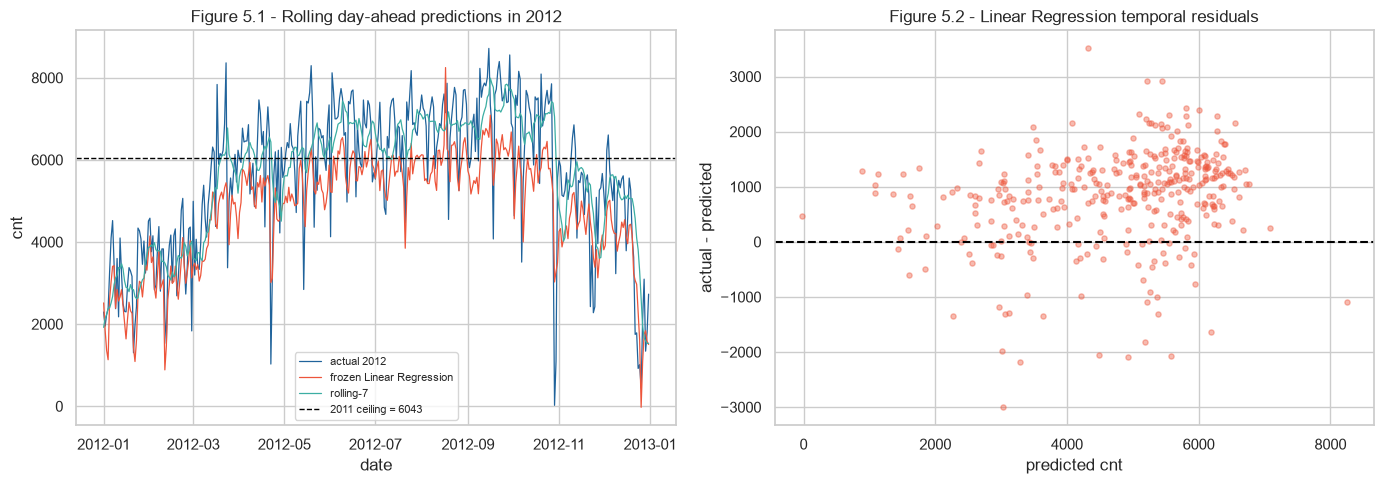

In [17]:
train_ceiling = int(temporal_train.cnt.max())
ceiling_rows = []
for name in list(GRIDS) + ["Naive rolling-7"]:
    pred = temporal_predictions[name]
    ceiling_rows.append({
        "model": name,
        "largest_2012_prediction": float(np.max(pred)),
        "2011_training_ceiling": train_ceiling,
        "2012_actual_maximum": int(temporal_test.cnt.max()),
        "mean_residual_actual_minus_prediction": float(np.mean(y2012 - pred)),
    })
extrapolation_ceiling = pd.DataFrame(ceiling_rows)
extrapolation_ceiling.to_csv(OUTPUT_DIR / "extrapolation_ceiling_v4.csv", index=False)
print("Table 5.3 - Extrapolation ceiling analysis")
display(extrapolation_ceiling.round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(temporal_test.dteday, y2012, lw=.9, color="#20639B", label="actual 2012")
ax[0].plot(temporal_test.dteday, selected_temporal_pred, lw=.9, color="#ED553B",
           label=f"frozen {temporal_winner_name}")
ax[0].plot(temporal_test.dteday, rolling_pred, lw=.9, color="#3CAEA3", label="rolling-7")
ax[0].axhline(train_ceiling, color="black", ls="--", lw=1, label=f"2011 ceiling = {train_ceiling}")
ax[0].set(title="Figure 5.1 - Rolling day-ahead predictions in 2012", xlabel="date", ylabel="cnt")
ax[0].legend(fontsize=8)
ax[1].scatter(selected_temporal_pred, y2012-selected_temporal_pred, s=14, alpha=.4, color="#ED553B")
ax[1].axhline(0, color="black", ls="--")
ax[1].set(title=f"Figure 5.2 - {temporal_winner_name} temporal residuals",
          xlabel="predicted cnt", ylabel="actual - predicted")
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_temporal_robustness.png", dpi=160); plt.show()

Tree ensembles predict averages within terminal regions and therefore have an extrapolation ceiling tied to observed training targets. The 2011 maximum was 6,043 rentals, while 2012 reached 8,714. Random Forest's largest prediction was 5,567 and Gradient Boosting's was 5,491; their mean under-predictions were 1,568 and 1,995 rentals per day. KNN also stayed below the training ceiling.

Linear Regression extended to 8,248 and reduced mean under-prediction to 832, explaining why it led the 2011-selected ML candidates. Rolling-7 reached 7,988 and had a mean residual of -2.5 because each new observation re-anchored the next prediction. Conditional accuracy within a mixed-year sample therefore did not transfer to the later growth period.

### 5.2 Explaining the frozen primary model

Permutation importance is model-agnostic and measures the increase in holdout MAE after one raw input is shuffled. It is computed only after model selection and does not change the winner. Contributions describe predictive associations in this dataset, not causal effects. TreeSHAP is added only when the frozen primary family is Random Forest or Gradient Boosting.

Table 5.4 - Model-agnostic permutation importance on the primary holdout


,feature,MAE_increase_mean,MAE_increase_std
0,days_since_start,950.28,53.08
1,atemp,409.77,41.65
2,hum,144.47,18.57
3,temp_sq,110.50,16.63
4,mnth,81.71,15.54
5,windspeed,76.41,15.94
6,weathersit,69.47,9.73
7,workingday,34.08,9.05
8,atemp_hum,29.41,6.80
9,temp,24.92,8.24


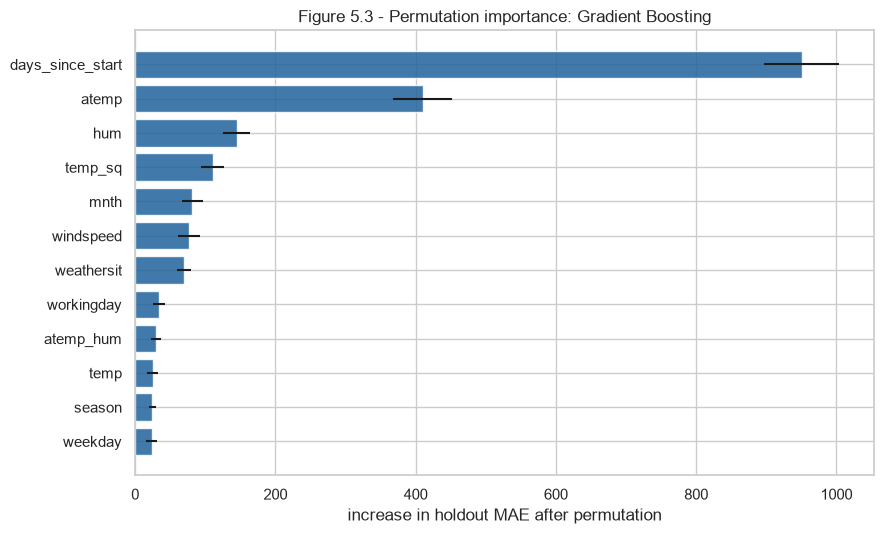

In [18]:
perm = permutation_importance(
    primary_winner, primary_holdout[primary_winner_columns], primary_holdout.cnt,
    scoring="neg_mean_absolute_error", n_repeats=30, random_state=RANDOM_STATE, n_jobs=1
)
permutation_table = (pd.DataFrame({
    "feature": primary_winner_columns,
    "MAE_increase_mean": perm.importances_mean,
    "MAE_increase_std": perm.importances_std,
}).sort_values("MAE_increase_mean", ascending=False).reset_index(drop=True))
permutation_table.to_csv(OUTPUT_DIR / "permutation_importance_v4.csv", index=False)
print("Table 5.4 - Model-agnostic permutation importance on the primary holdout")
display(permutation_table.head(12).round(2))

top_perm = permutation_table.head(12).sort_values("MAE_increase_mean")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_perm.feature, top_perm.MAE_increase_mean, xerr=top_perm.MAE_increase_std,
        color="#20639B", alpha=.85)
ax.set(title=f"Figure 5.3 - Permutation importance: {primary_winner_name}",
       xlabel="increase in holdout MAE after permutation", ylabel="")
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_permutation_importance.png", dpi=160); plt.show()

Table 5.5 - TreeSHAP global importance for the frozen primary model


,feature,mean_absolute_SHAP
0,continuous__days_since_start,1018.06
1,continuous__atemp,586.20
2,continuous__hum,234.58
3,continuous__temp_sq,201.12
4,continuous__windspeed,136.82
5,continuous__temp,119.90
6,nominal__weathersit_2,97.63
7,binary__workingday,87.97
8,nominal__weekday_6,69.75
9,nominal__mnth_8,55.72


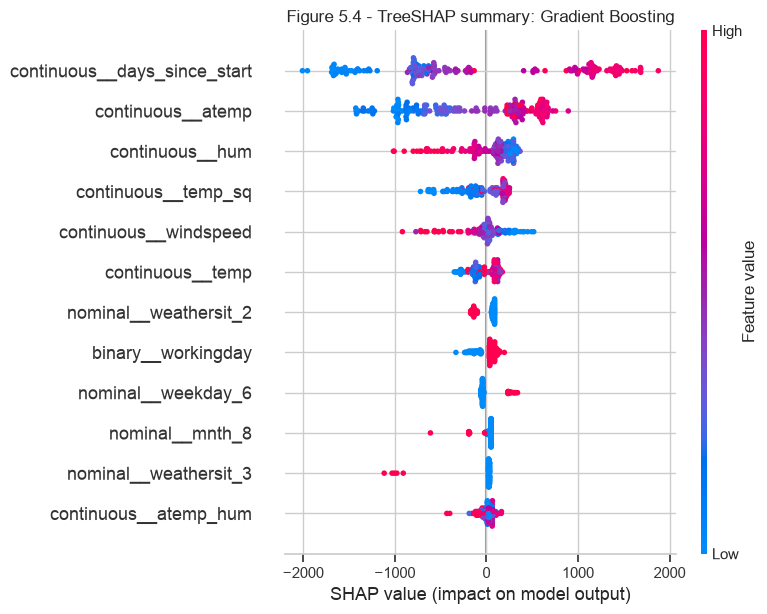

In [19]:
shap_table = None
if primary_winner_name in {"Random Forest", "Gradient Boosting"}:
    import shap
    fitted_prep = primary_winner.named_steps["prep"]
    transformed = fitted_prep.transform(primary_holdout[primary_winner_columns])
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    transformed_names = fitted_prep.get_feature_names_out()
    explainer = shap.TreeExplainer(primary_winner.named_steps["model"])
    shap_values = explainer.shap_values(transformed, check_additivity=True)
    shap_table = (pd.DataFrame({"feature": transformed_names,
                                "mean_absolute_SHAP": np.abs(shap_values).mean(axis=0)})
                  .sort_values("mean_absolute_SHAP", ascending=False).reset_index(drop=True))
    shap_table.to_csv(OUTPUT_DIR / "shap_global_importance_v4.csv", index=False)
    print("Table 5.5 - TreeSHAP global importance for the frozen primary model")
    display(shap_table.head(12).round(2))
    shap.summary_plot(shap_values, transformed, feature_names=transformed_names,
                      max_display=12, show=False)
    plt.title(f"Figure 5.4 - TreeSHAP summary: {primary_winner_name}")
    plt.tight_layout(); plt.savefig(FIG_DIR / "v4_shap_summary.png", dpi=160, bbox_inches="tight"); plt.show()
else:
    print("TreeSHAP omitted: the frozen primary winner is", primary_winner_name)

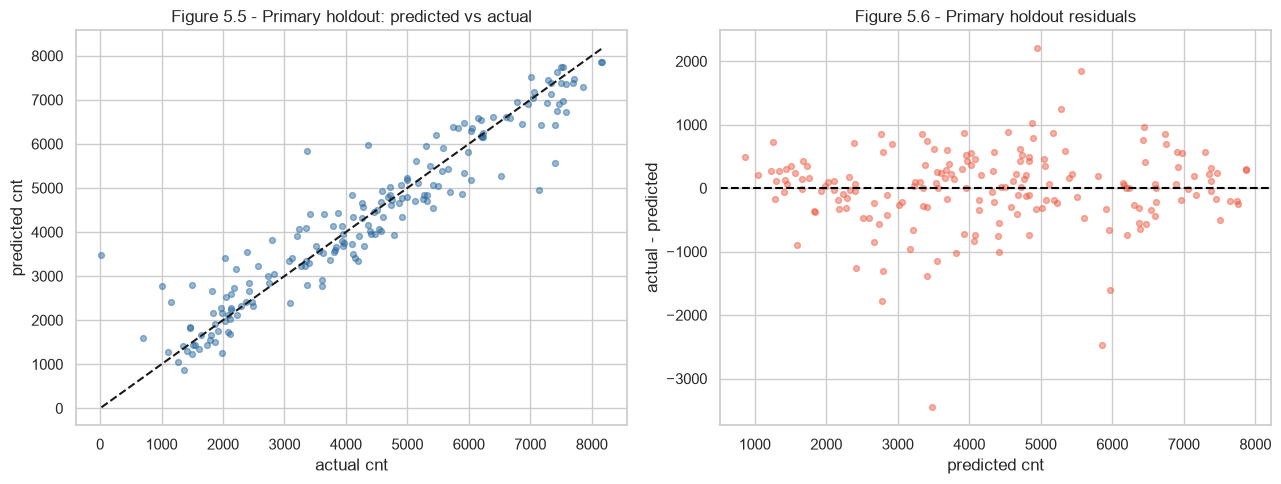

In [20]:
primary_pred = primary_winner.predict(primary_holdout[primary_winner_columns])
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(primary_holdout.cnt, primary_pred, alpha=.45, s=18, color="#20639B")
lims = [min(primary_holdout.cnt.min(), primary_pred.min()),
        max(primary_holdout.cnt.max(), primary_pred.max())]
ax[0].plot(lims, lims, "k--")
ax[0].set(title="Figure 5.5 - Primary holdout: predicted vs actual",
          xlabel="actual cnt", ylabel="predicted cnt")
ax[1].scatter(primary_pred, primary_holdout.cnt-primary_pred, alpha=.45, s=18, color="#ED553B")
ax[1].axhline(0, color="black", ls="--")
ax[1].set(title="Figure 5.6 - Primary holdout residuals",
          xlabel="predicted cnt", ylabel="actual - predicted")
plt.tight_layout(); plt.savefig(FIG_DIR / "v4_primary_diagnostics.png", dpi=160); plt.show()

### 5.3 Interpretation

Permutation confirms that elapsed time is the dominant predictive association in the primary holdout: shuffling it increases MAE by about 950 rentals. Feels-like temperature follows at 410, then humidity at 144 and squared temperature at 111. TreeSHAP produces the same leading order, with mean absolute contributions of about 1,018, 586, 235 and 201 rentals. These values explain predictions across the observed sample; they do not imply that advancing time causes demand or that weather effects are causal.

The primary result is MAE 433.9, RMSE 630.6 and R-squared 0.897: 73.9% better than the baseline and 10.1% of mean holdout demand. Temporally, Linear Regression lost to rolling-7 by 23.5%; median error was 1,045 versus 636, with wins on 116 versus 250 dates. This paired description makes no independence claim.

## 6. Lessons Learned

### 6.1 What went well

All 731 daily units remain available, the holdout is isolated from selection, and four families compete across three exogenous feature sets. The hourly file validates every daily total and exposes intraday peaks and panel imbalance. Separate frames preserve the full primary sample and causal temporal lags.

### 6.2 Challenges

The zero-humidity correction had to preserve sample size and avoid fold leakage; pipeline imputation and sensitivity analysis provide that control. Temporal growth is harder: a tree can interpolate across both years yet fail to reach 2012 demand when trained on 2011. Observed weather also omits real forecast error.

### 6.3 What can be improved

Deployment was not required. A stronger study needs more years, archived weather forecasts and repeated forward windows. Station planning also requires identifiers, dock capacity, origins, destinations, transit connections and local demand. ITDP and NACTO show why network integration, spacing and context matter. Category-4 weather remains outside the supported domain.

Future work could compare trend-seasonality models, differenced targets and forecast-aware inputs. Operational use still requires new forward evidence, monitoring, human review and decision-appropriate station data.

---

## Appendix A - Glossary

| Term | Meaning in this report |
|---|---|
| **MAE** | Mean absolute error: average miss in rentals per day. |
| **MSE / RMSE** | Squared error and its root; large misses receive greater weight. |
| **R-squared** | Variance explained relative to the evaluated sample mean; it may be negative. |
| **Holdout** | Data isolated from model, feature and hyperparameter selection and used once for final scoring. |
| **Interpolation** | Prediction within a domain represented in training. |
| **Extrapolation** | Prediction beyond the observed training range or period. |
| **Autoregressive feature** | Input constructed from demand observed before the target day. |
| **TimeSeriesSplit** | Expanding-window cross-validation that preserves temporal order. |
| **Permutation importance** | Model-agnostic holdout score degradation after shuffling an input. |
| **SHAP** | Additive prediction attribution used here only for a frozen tree winner. |

## Appendix B - Reproducibility and integrity evidence

In [21]:
import sys
import sklearn
import matplotlib

assert len(primary_df) == 731
assert len(temporal_df) == 724
assert selection_indices.isdisjoint(set(primary_holdout_idx))
assert temporal_train.yr.eq(0).all()
assert temporal_train.dteday.max() < temporal_test.dteday.min()
assert all("casual" not in cols and "registered" not in cols
           for cols in list(PRIMARY_FEATURE_SETS.values()) + list(TEMPORAL_FEATURE_SETS.values()))
assert all(c not in cols for cols in PRIMARY_FEATURE_SETS.values() for c in AUTOREGRESSIVE)
assert cross_file.difference.eq(0).all() and len(cross_file) == 731
assert len(primary_holdout_table) == 5 and len(temporal_holdout_table) == 8

integrity = pd.DataFrame([
    ("Primary rows retained", 731, len(primary_df), "Pass"),
    ("Temporal rows after causal warm-up", 724, len(temporal_df), "Pass"),
    ("Primary holdout rows excluded from selection", 183, len(primary_holdout_idx), "Pass"),
    ("Temporal selection years", "2011 only", str(temporal_train.dteday.dt.year.unique().tolist()), "Pass"),
    ("Hourly/daily dates reconciled", 731, int(cross_file.difference.eq(0).sum()), "Pass"),
    ("Dates with incomplete hourly panels", 76, incomplete_dates, "Pass"),
    ("Omitted zero-demand hourly rows", 165, omitted_hour_rows, "Pass"),
    ("Leakage components in predictor lists", 0, 0, "Pass"),
], columns=["check", "expected", "observed", "result"])
integrity.to_csv(OUTPUT_DIR / "integrity_checks_v4.csv", index=False)
display(integrity)
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__,
      "| scikit-learn:", sklearn.__version__, "| matplotlib:", matplotlib.__version__)
print("RANDOM_STATE:", RANDOM_STATE)

,check,expected,observed,result
0,Primary rows retained,731,731,Pass
1,Temporal rows after causal warm-up,724,724,Pass
2,Primary holdout rows excluded from selection,183,183,Pass
3,Temporal selection years,2011 only,[2011],Pass
4,Hourly/daily dates reconciled,731,731,Pass
5,Dates with incomplete hourly panels,76,76,Pass
6,Omitted zero-demand hourly rows,165,165,Pass
7,Leakage components in predictor lists,0,0,Pass


Python: 3.14.3 | pandas: 3.0.3 | scikit-learn: 1.9.0 | matplotlib: 3.11.0
RANDOM_STATE: 42


---

## Academic Integrity Declaration

I declare that this submission is my own work. All sources of information, ideas and code have been acknowledged. The dataset is publicly available from the UCI Machine Learning Repository. The analysis, modelling decisions, interpretation and written commentary are my own.

## Statement of Acknowledgement

Analysis was performed in Python with pandas, NumPy, scikit-learn, Matplotlib, Seaborn and, when applicable, SHAP. I used AI assistants (Anthropic Claude and OpenAI Codex) as study and review aids to challenge the experimental design, audit empirical claims, implement the reproducible notebook and check that narrative metrics matched executed outputs. I reviewed and accepted the final modelling decisions, interpretations and submission.

## References

Capital Bikeshare. (n.d.). *How it works*. https://capitalbikeshare.com/how-it-works

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence, 2*, 113-127. https://doi.org/10.1007/s13748-013-0040-3

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451

Institute for Transportation & Development Policy. (2018). *The bikeshare planning guide*. https://itdp.org/publication/the-bike-share-planning-guide/

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*, 4765-4774.

National Association of City Transportation Officials. (2016). *Bike share station siting guide*. https://nacto.org/publication/bike-share-station-siting-guide/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Bike Sharing Dataset*. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset